In [1]:
# Import thư viện: 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

import os
from scipy.sparse import coo_matrix

In [ ]:
# Đọc dữ liệu: 
product = pd.read_csv('product_details.csv')

In [25]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Uniqe Id               10002 non-null  object 
 1   Product Name           10002 non-null  object 
 2   Brand Name             0 non-null      float64
 3   Asin                   0 non-null      float64
 4   Category               9172 non-null   object 
 5   Upc Ean Code           34 non-null     object 
 6   List Price             0 non-null      float64
 7   Selling Price          9895 non-null   object 
 8   Quantity               0 non-null      float64
 9   Model Number           8230 non-null   object 
 10  About Product          9729 non-null   object 
 11  Product Specification  8370 non-null   object 
 12  Technical Details      9212 non-null   object 
 13  Shipping Weight        8864 non-null   object 
 14  Product Dimensions     479 non-null    object 
 15  Im

In [26]:
product.columns

Index(['Uniqe Id', 'Product Name', 'Brand Name', 'Asin', 'Category',
       'Upc Ean Code', 'List Price', 'Selling Price', 'Quantity',
       'Model Number', 'About Product', 'Product Specification',
       'Technical Details', 'Shipping Weight', 'Product Dimensions', 'Image',
       'Variants', 'Sku', 'Product Url', 'Stock', 'Product Details',
       'Dimensions', 'Color', 'Ingredients', 'Direction To Use',
       'Is Amazon Seller', 'Size Quantity Variant', 'Product Description'],
      dtype='object')

In [27]:
product['Technical Details'].values

array([nan,
       'The snap circuits mini kits classpack provides basic electric circuitry information for students in grades 2-6. This classpack includes 5 snap-together building kits. Components snap together to create working models of everyday electronic devices. Kits included are an FM radio, a motion detector, a music box, space battle sound effects, and a flying saucer. Each mini kit comes with individual components, and an activity guide which includes instructions and additional project ideas. Each primary-colored component represents one function in a circuit. Activity kits are used by teachers and students in classroom and homeschool settings for educational and research applications in science, math, and for a variety of additional disciplines. Science education products and manipulatives incorporate applied math and science principles into classroom or homeschool projects. Teachers in pre-K, elementary, and secondary classrooms use science education kits, manipualtives, a

In [28]:
customer = pd.read_csv('customer_details.csv')

In [29]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [30]:
customer.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [31]:
sales = pd.read_csv('sale.csv')

In [32]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3294 entries, 0 to 3293
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user id           2999 non-null   float64
 1   product id        2999 non-null   object 
 2   Interaction type  2871 non-null   object 
 3   Time stamp        2999 non-null   object 
 4   Unnamed: 4        0 non-null      float64
dtypes: float64(2), object(3)
memory usage: 128.8+ KB


In [33]:
sales.head()

,user id,product id,Interaction type,Time stamp,Unnamed: 4
0,1.0,4c69b61db1fc16e7013b43fc926e502d,purchase,10/10/2023 8:00,NaN
1,2.0,66d49bbed043f5be260fa9f7fbff5957,view,11/10/2023 8:00,NaN
2,3.0,2c55cae269aebf53838484b0d7dd931a,like,12/10/2023 8:00,NaN
3,4.0,18018b6bc416dab347b1b7db79994afa,view,13/10/2023 8:00,NaN
4,5.0,e04b990e95bf73bbe6a3fa09785d7cd0,like,14/10/2023 8:00,NaN


In [34]:
sales_with_products = pd.merge(sales, product, left_on='product id', right_on='Uniqe Id', how='inner')

In [35]:
customer['Customer ID'] = customer['Customer ID'].astype(float)


In [36]:
full_data = pd.merge(customer,sales_with_products, left_on='Customer ID', right_on='user id', how='inner')

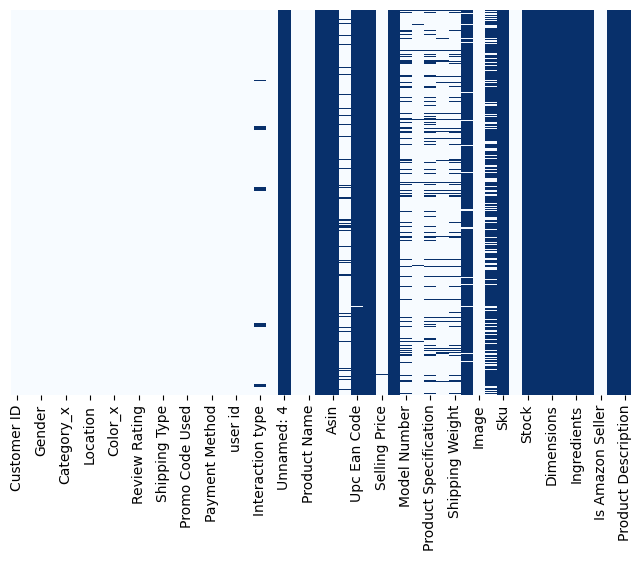

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(full_data.isna(), cmap="Blues", cbar=False, yticklabels=False)
plt.show()


In [38]:
full_data.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category_x',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color_x', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases', 'user id', 'product id',
       'Interaction type', 'Time stamp', 'Unnamed: 4', 'Uniqe Id',
       'Product Name', 'Brand Name', 'Asin', 'Category_y', 'Upc Ean Code',
       'List Price', 'Selling Price', 'Quantity', 'Model Number',
       'About Product', 'Product Specification', 'Technical Details',
       'Shipping Weight', 'Product Dimensions', 'Image', 'Variants', 'Sku',
       'Product Url', 'Stock', 'Product Details', 'Dimensions', 'Color_y',
       'Ingredients', 'Direction To Use', 'Is Amazon Seller',
       'Size Quantity Variant', 'Product Description'],
      dtype='object')

In [39]:
train_data = full_data[['user id','product id','Review Rating','Interaction type','Product Name','Category_y','Technical Details','Image']]

In [40]:
train_data.isna().sum()

user id                0
product id             0
Review Rating          0
Interaction type     128
Product Name           0
Category_y           275
Technical Details    211
Image                  0
dtype: int64

In [41]:
column_name_mapping = {
    'Interaction type' : 'Nothing',
    'Category_y' : 'Unknown',
    'Technical Details' : 'Unknown'

}
for column, fill_value in column_name_mapping.items():
    train_data[column].fillna(fill_value, inplace=True)

# Kết quả
print(train_data)

      user id                        product id  Review Rating  \
0         1.0  4c69b61db1fc16e7013b43fc926e502d            3.1   
1         2.0  66d49bbed043f5be260fa9f7fbff5957            3.1   
2         3.0  2c55cae269aebf53838484b0d7dd931a            3.1   
3         4.0  18018b6bc416dab347b1b7db79994afa            3.5   
4         5.0  e04b990e95bf73bbe6a3fa09785d7cd0            2.7   
...       ...                               ...            ...   
2994   2995.0  f5149cfb8e04d7b30bd7b4eaed6713b8            3.5   
2995   2996.0  82318e8acf79bbeb3cf685a2732fb630            2.5   
2996   2997.0  19d150365d798db47cccf1622b6ad754            2.9   
2997   2998.0  136c0aff3ab56bd3d138775fe90ef970            2.7   
2998   2999.0  a2c6dd69f022a658c5bcc2b3b52970f2            4.7   

     Interaction type                                       Product Name  \
0            purchase  DB Longboards CoreFlex Crossbow 41" Bamboo Fib...   
1                view  Electronic Snap Circuits Mini Ki

C:\Users\Admin\AppData\Local\Temp\ipykernel_18980\2309346147.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data[column].fillna(fill_value, inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_18980\2309346147.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data[column].fillna(fill_value, inplace=True)


In [42]:
train_data.isna().sum()

user id              0
product id           0
Review Rating        0
Interaction type     0
Product Name         0
Category_y           0
Technical Details    0
Image                0
dtype: int64

In [43]:
column_name_mapping = {
    'Interaction type' : 'Interaction' ,
    'Category_y' :'Category' , 
    'user id' : 'ID',
    'product id' : 'ProdID',
    'Product Name' : 'Name'
}
train_data.rename(columns=column_name_mapping, inplace=True)

train_data.head(3)

C:\Users\Admin\AppData\Local\Temp\ipykernel_18980\3356067384.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data.rename(columns=column_name_mapping, inplace=True)


,ID,ProdID,Review Rating,Interaction,Name,Category,Technical Details,Image
0,1.0,4c69b61db1fc16e7013b43fc926e502d,3.1,purchase,"DB Longboards CoreFlex Crossbow 41"" Bamboo Fib...",Sports & Outdoors | Outdoor Recreation | Skate...,Unknown,https://images-na.ssl-images-amazon.com/images...
1,2.0,66d49bbed043f5be260fa9f7fbff5957,3.1,view,"Electronic Snap Circuits Mini Kits Classpack, ...",Toys & Games | Learning & Education | Science ...,The snap circuits mini kits classpack provides...,https://images-na.ssl-images-amazon.com/images...
2,3.0,2c55cae269aebf53838484b0d7dd931a,3.1,like,3Doodler Create Flexy 3D Printing Filament Ref...,Toys & Games | Arts & Crafts | Craft Kits,show up to 2 reviews by default No longer are ...,https://images-na.ssl-images-amazon.com/images...


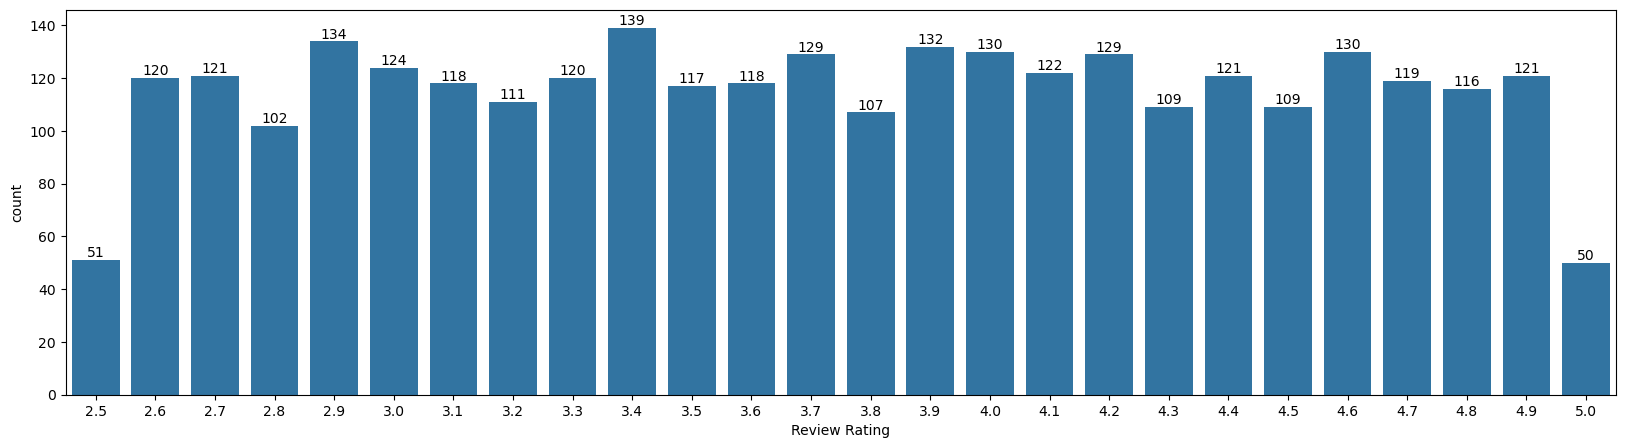

In [44]:
plt.figure(figsize=(20,5))
ax = sns.countplot(data=train_data,x='Review Rating')
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Review Rating'>

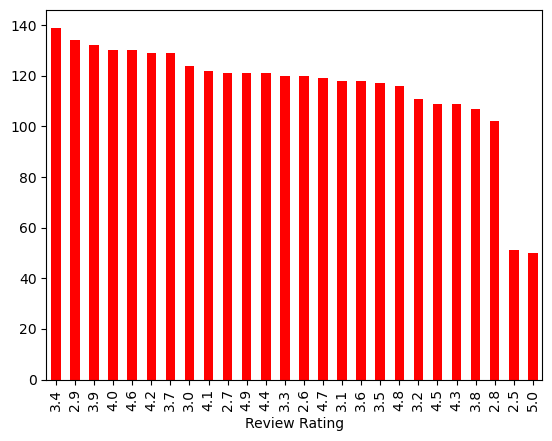

In [45]:
# most rated counts
train_data['Review Rating'].value_counts().plot(kind='bar',color='red')

In [46]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 2999 non-null   float64
 1   ProdID             2999 non-null   object 
 2   Review Rating      2999 non-null   float64
 3   Interaction        2999 non-null   object 
 4   Name               2999 non-null   object 
 5   Category           2999 non-null   object 
 6   Technical Details  2999 non-null   object 
 7   Image              2999 non-null   object 
dtypes: float64(2), object(6)
memory usage: 187.6+ KB


In [47]:
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

nlp = spacy.load("en_core_web_sm")

def clean_and_extract_tags(text):
    doc = nlp(text.lower())
    tags = [token.text for token in doc if token.text.isalnum() and token.text not in STOP_WORDS]
    return ', '.join(tags)

columns_to_extract_tags_from = ['Category', 'Name','Technical Details']

for column in columns_to_extract_tags_from:
    train_data[column] = train_data[column].apply(clean_and_extract_tags)

C:\Users\Admin\AppData\Local\Temp\ipykernel_18980\2024679962.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data[column] = train_data[column].apply(clean_and_extract_tags)


In [48]:
train_data['Tags'] = train_data[columns_to_extract_tags_from].apply(lambda row: ', '.join(row), axis=1)

C:\Users\Admin\AppData\Local\Temp\ipykernel_18980\3959361717.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['Tags'] = train_data[columns_to_extract_tags_from].apply(lambda row: ', '.join(row), axis=1)


In [49]:
train_data['Tags'].values

array(['sports, outdoors, outdoor, recreation, skates, skateboards, scooters, skateboarding, standard, skateboards, longboards, longboards, db, longboards, coreflex, crossbow, 41, bamboo, fiberglass, longboard, complete, unknown',
       'toys, games, learning, education, science, kits, toys, electronic, snap, circuits, mini, kits, classpack, fm, radio, motion, detector, music, box, set, 5, snap, circuits, mini, kits, classpack, provides, basic, electric, circuitry, information, students, grades, 2, 6, classpack, includes, 5, snap, building, kits, components, snap, create, working, models, everyday, electronic, devices, kits, included, fm, radio, motion, detector, music, box, space, battle, sound, effects, flying, saucer, mini, kit, comes, individual, components, activity, guide, includes, instructions, additional, project, ideas, primary, colored, component, represents, function, circuit, activity, kits, teachers, students, classroom, homeschool, settings, educational, research, appli

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def content_based_recommendations(train_data, item_name, top_n=10):
    # Check if the item name exists in the training data
    if item_name not in train_data['Name'].values:
        print(f"Item '{item_name}' not found in the training data.")
        return pd.DataFrame()

    # Create a TF-IDF vectorizer for item descriptions
    tfidf_vectorizer = TfidfVectorizer(stop_words='english')

    # Apply TF-IDF vectorization to item descriptions
    tfidf_matrix_content = tfidf_vectorizer.fit_transform(train_data['Tags'])

    # Calculate cosine similarity between items based on descriptions
    cosine_similarities_content = cosine_similarity(tfidf_matrix_content, tfidf_matrix_content)

    # Find the index of the item
    item_index = train_data[train_data['Name'] == item_name].index[0]

    # Get the cosine similarity scores for the item
    similar_items = list(enumerate(cosine_similarities_content[item_index]))

    # Sort similar items by similarity score in descending order
    similar_items = sorted(similar_items, key=lambda x: x[1], reverse=True)

    # Get the top N most similar items (excluding the item itself)
    top_similar_items = similar_items[1:top_n+1]

    # Get the indices of the top similar items
    recommended_item_indices = [x[0] for x in top_similar_items]

    # Get the details of the top similar items
    recommended_items_details = train_data.iloc[recommended_item_indices][['Name' , 'Image','Review Rating']]

    return recommended_items_details

In [51]:
train_data['Name'].values

array(['db, longboards, coreflex, crossbow, 41, bamboo, fiberglass, longboard, complete',
       'electronic, snap, circuits, mini, kits, classpack, fm, radio, motion, detector, music, box, set, 5',
       '3doodler, create, flexy, 3d, printing, filament, refill, bundle, x5, pack, 1000, extruded, plastics, innovate',
       ...,
       'uxcell, 1500, a12121200ux0003, 10000rpm, dc3, 12v, high, torque, motor, propeller, model, aircraft',
       'zvezda, 5023, german, king, tiger, ausf, b, henschel, turret, heavy, tank, snap',
       'dc, comics, shazam, eugene, action, figure'], dtype=object)

In [52]:
item_name = 'dc, comics, shazam, eugene, action, figure'
content_based_rec = content_based_recommendations(train_data, item_name, top_n=8)

content_based_rec

,Name,Image,Review Rating
1421,"dc, comics, multiverse, dc, rebirth, ray, figure",https://images-na.ssl-images-amazon.com/images...,3.0
1903,"jurassic, world, basic, figure, zia, triceratops",https://images-na.ssl-images-amazon.com/images...,3.3
2846,"wwe, big, cass, elite, collection, action, figure",https://images-na.ssl-images-amazon.com/images...,2.8
2807,"dc, super, hero, girls, batgirl, 6, action, fi...",https://images-na.ssl-images-amazon.com/images...,4.4
2411,"wwe, kurt, angle, action, figure",https://images-na.ssl-images-amazon.com/images...,2.7
135,"wwe, rey, mysterio, elite, collection, action,...",https://images-na.ssl-images-amazon.com/images...,4.1
269,"wwe, rowan, elite, collection, action, figure",https://images-na.ssl-images-amazon.com/images...,3.3
1892,"mattel, dc, comics, multiverse, suicide, squad...",https://images-na.ssl-images-amazon.com/images...,4.6


In [53]:
train_data.to_csv('clean_data.csv', index=False)
